In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

In [3]:
df_pg = df[df['pos'] == 'PG'].copy()

print("Nombre de PG :", df_pg.shape[0])

Nombre de PG : 1347


On utilise les statistiques présélectionnées. 

In [4]:
pg_stats = [
    "ast_percent",
    "usg_percent",
    "tov_percent",
    "ts_percent",
    "x3p_ar",
    "stl_percent",
]

X_pg = df_pg[pg_stats]


On met les stastiques à la même échelle avant d'éviter une influence excessive des données brutes des données relatives. 

In [5]:
scaler = StandardScaler()
X_pg_scaled = scaler.fit_transform(X_pg)

On utilise les PCA (Principal Component Analysis) pour résumer les statistiques utilisés en quelques axes synthétiques et ainsi pouvoir visualiser quelles statistiques permettent de classer les joueurs. On fixe la variance cumulée au moins à 0,7 afin d'être suffisament précis pour classer les joueurs de façons pertinentes sans rentrer dans des groupes ultra spécifiques. 

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_pg_scaled)

explained_var = pca.explained_variance_ratio_

cumulative_var = np.cumsum(explained_var)

print(explained_var)
print(cumulative_var)

[0.29783482 0.26906277 0.1603765  0.13413646 0.09748508 0.04110437]
[0.29783482 0.56689759 0.72727409 0.86141054 0.95889563 1.        ]


On prendra donc 3 PCA pour les PG.

In [7]:
pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_pg_scaled)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=pg_stats
)

print("Loadings PCA :")
print(loadings)

Loadings PCA :
                 PCA1      PCA2      PCA3
ast_percent  0.648830  0.156917  0.101521
usg_percent  0.421109  0.540997 -0.154720
tov_percent  0.317105 -0.526761  0.154140
ts_percent  -0.039714  0.565137  0.453187
x3p_ar      -0.481770  0.157834  0.457161
stl_percent  0.259715 -0.246843  0.726376


On cherche à determiner le nombre de clusters le plus pertinent pour le poste à l'aide de la méthode du coude et du score de silouhette .

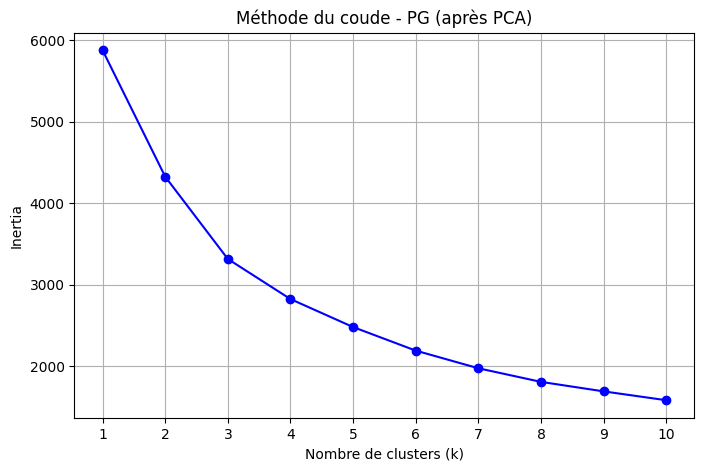

In [8]:
inertia_list = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_result)  
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - PG (après PCA)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [9]:
inertia_c = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_c

,k,inertia
0,1,5877.829185
1,2,4324.698077
2,3,3313.872156
3,4,2821.689688
4,5,2477.981446
5,6,2188.600762
6,7,1971.790784
7,8,1804.670840
8,9,1688.020704
9,10,1579.300735


In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    'k': range(2, 11),
    'silhouette_score': silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.252980
1,3,0.254766
2,4,0.239038
3,5,0.247306
4,6,0.246070
5,7,0.247178
6,8,0.248801
7,9,0.240008
8,10,0.235594


In [11]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_pg['cluster'] = kmeans.fit_predict(pca_result)

Le nombre de clusters a été déterminé à l’aide de la méthode du coude et du score de silhouette.
Bien que le score de silhouette soit maximal pour k=2, ce choix produit une segmentation trop grossière d’un point de vue basketball.
Le choix k=3 représente un compromis optimal entre séparation statistique et interprétabilité métier, permettant d’identifier trois profils distincts de meneurs NBA.

In [12]:
cluster_means = df_pg.groupby('cluster')[pg_stats].mean()
cluster_means

,ast_percent,usg_percent,tov_percent,ts_percent,x3p_ar,stl_percent
cluster,,,,,,
0,20.025486,17.963619,13.243774,0.539648,0.470422,1.699027
1,33.197351,26.190066,14.070861,0.559325,0.337038,1.811479
2,27.866842,18.666053,18.609737,0.495608,0.279034,2.102105


cluster 0:
taux d'assist plutôt élevé , gros turn-over, true shoot plutôt faible, faible taux de tir à 3 points, et BPM négatif.
Profil type: meneur créateur mais inefficace. 
cluster 1: 
fort taux d'assist, gros usage, bon shoot et équilibré en shoot à 3 points. très gros BPM
Profil type: meneur star , gros scoreur et créateur de jeu .
cluster 2:
faible taux d'assist, bon shoot, très grosse proportion de tirs à 3points
Profil type: bon meneur, privilégiant le shoot extérieur à la création de jeu, souvent un bon meneur qui n'est pas la star de son équipe. 

In [13]:
import plotly.express as px
import pandas as pd


plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'cluster': df_pg['cluster'],
    'player': df_pg['player'],
    'team': df_pg['team'],
    'season': df_pg['season']
})


fig = px.scatter(
    plot_df,
    x='PCA1',
    y='PCA2',
    color='cluster',
    hover_data=['player', 'team', 'season'],
    title="Clusters PG (PCA1 vs PCA2)",
    width=900,
    height=600
)

fig.show()

In [14]:
df_pg['cluster'] = kmeans.fit_predict(pca_result)


df_pg.to_csv("../data/processed/nba_pg_clusters_full.csv", index=False)

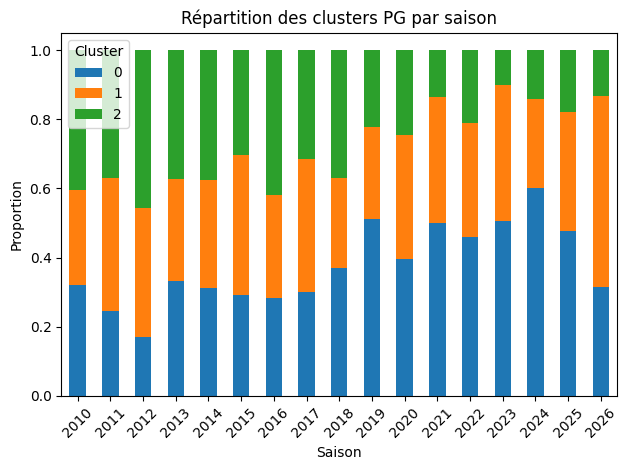

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df_pg = pd.read_csv("../data/processed/nba_pg_clusters_full.csv")


counts = df_pg.groupby(['season', 'cluster']).size().reset_index(name='count')

totals = df_pg.groupby('season').size().reset_index(name='total')

counts = counts.merge(totals, on='season')
counts['proportion'] = counts['count'] / counts['total']


pivot = counts.pivot(index='season', columns='cluster', values='proportion')


pivot.plot(kind='bar', stacked=True)

plt.title("Répartition des clusters PG par saison")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On constate une évolution très net des types de PG au cours des 15 dernières saisons. Si les PG de type 1 sont restés relativement constant, on constate une très large évolution de ce type sur les deux dernières saisons. En revanche, le cluster 0 a bien augmenté de 2013 à 2024 puis s'est estompé dernièrement. Enfin, les PG de type 2 ont diminués progressivements. Ils étaient majoritaires en 2010 puis largement minoritaires 10 ans plus tard. 